In [1]:
!pip install scikit-learn pandas joblib gradio shap

   ---------------------------------------- 0.0/63.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/63.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/63.5 MB 1.4 MB/s eta 0:00:46
   ---------------------------------------- 0.8/63.5 MB 1.4 MB/s eta 0:00:45
    --------------------------------------- 1.0/63.5 MB 1.2 MB/s eta 0:00:53
    --------------------------------------- 1.3/63.5 MB 1.2 MB/s eta 0:00:51
    --------------------------------------- 1.6/63.5 MB 1.3 MB/s eta 0:00:47
   - -------------------------------------- 2.1/63.5 MB 1.3 MB/s eta 0:00:46
   - -------------------------------------- 2.4/63.5 MB 1.3 MB/s eta 0:00:46
   - -------------------------------------- 2.6/63.5 MB 1.4 MB/s eta 0:00:44
   - -------------------------------------- 3.1/63.5 MB 1.5 MB/s eta 0:00:41
   -- ------------------------------------- 3.4/63.5 MB 1.5 MB/s eta 0:00:41
   -- ------------------------------------- 3.7/63.5 MB 1.4 MB/s eta 0:00:43
   -- -------

In [5]:
import pandas as pd

data = pd.read_csv("ai4i2020.csv")
data.head()
print(data.columns.tolist())


['UDI', 'Product ID', 'Type', 'Air_temperature', 'Process_temperature ', 'Rotational_speed ', 'Torque ', 'Tool_wear', 'Machine_failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Example columns (adjust based on the CSV)
# Clean column names to remove leading/trailing spaces
data.columns = data.columns.str.strip()

# Example columns (adjusted based on cleaned CSV)
FEATURES = ['Air_temperature', 'Process_temperature', 
            'Rotational_speed', 'Torque', 
            'Tool_wear']
TARGET = 'Machine_failure'  # adjust column name if needed

# Features & target
X = data[FEATURES]
y = data[TARGET]

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

# Train RandomForest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate
y_pred = model.predict(X_test_scaled)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Save model & scaler
joblib.dump(model, "model_ai4i_rf.joblib")
joblib.dump(scaler, "scaler_ai4i.joblib")


Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.90      0.63      0.74        68

    accuracy                           0.98      2000
   macro avg       0.94      0.81      0.87      2000
weighted avg       0.98      0.98      0.98      2000

Confusion Matrix:
 [[1927    5]
 [  25   43]]


['scaler_ai4i.joblib']

In [15]:
!pip install xgboost

   ---------------------------------------- 0.0/56.8 MB ? eta -:--:--
   ---------------------------------------- 0.3/56.8 MB ? eta -:--:--
    --------------------------------------- 0.8/56.8 MB 2.4 MB/s eta 0:00:24
   - -------------------------------------- 1.6/56.8 MB 2.7 MB/s eta 0:00:21
   - -------------------------------------- 2.1/56.8 MB 2.9 MB/s eta 0:00:20
   - -------------------------------------- 2.6/56.8 MB 2.8 MB/s eta 0:00:20
   -- ------------------------------------- 2.9/56.8 MB 2.8 MB/s eta 0:00:20
   -- ------------------------------------- 3.7/56.8 MB 2.5 MB/s eta 0:00:21
   -- ------------------------------------- 4.2/56.8 MB 2.5 MB/s eta 0:00:21
   --- ------------------------------------ 4.7/56.8 MB 2.5 MB/s eta 0:00:21
   --- ------------------------------------ 5.0/56.8 MB 2.4 MB/s eta 0:00:22
   --- ------------------------------------ 5.2/56.8 MB 2.4 MB/s eta 0:00:22
   ---- ----------------------------------- 5.8/56.8 MB 2.4 MB/s eta 0:00:22
   ---- -----

In [13]:
# Remove special characters from feature names
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()
X_train_clean.columns = [c.replace('[','').replace(']','').replace('<','').replace(' ','_') for c in X_train_clean.columns]
X_test_clean.columns = [c.replace('[','').replace(']','').replace('<','').replace(' ','_') for c in X_test_clean.columns]

# Train XGBoost
import xgboost as xgb

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_clean, y_train)
y_pred_xgb = xgb_model.predict(X_test_clean)

from sklearn.metrics import classification_report
print("XGBoost:\n", classification_report(y_test, y_pred_xgb))


C:\Users\Priya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [22:02:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.83      0.66      0.74        68

    accuracy                           0.98      2000
   macro avg       0.91      0.83      0.86      2000
weighted avg       0.98      0.98      0.98      2000



In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer=Adam(learning_rate=0.001),
                 loss='binary_crossentropy', metrics=['accuracy'])

history = nn_model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=50, batch_size=32)

# Evaluate
nn_eval = nn_model.evaluate(X_test_scaled, y_test)
print(f"Neural Network Test Loss: {nn_eval[0]:.4f}, Accuracy: {nn_eval[1]*100:.2f}%")


C:\Users\Priya\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9341 - loss: 0.3026 - val_accuracy: 0.9656 - val_loss: 0.1409
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9648 - loss: 0.1369 - val_accuracy: 0.9706 - val_loss: 0.1103
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9667 - loss: 0.1056 - val_accuracy: 0.9700 - val_loss: 0.1013
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9705 - loss: 0.0965 - val_accuracy: 0.9694 - val_loss: 0.0938
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9683 - loss: 0.0898 - val_accuracy: 0.9675 - val_loss: 0.0915
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9752 - loss: 0.0759 - val_accuracy: 0.9706 - val_loss: 0.0861
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9717 - loss: 0.0845 - val_accuracy: 0.9725 - val_loss: 0.0790
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9709 - loss: 0.0839 - val_accuracy: 0.

In [17]:
import numpy as np
from tensorflow.keras.layers import LSTM

# Example: 10-minute sequences
sequence_length = 10
X_seq, y_seq = [], []

for i in range(len(X_train_scaled) - sequence_length):
    X_seq.append(X_train_scaled[i:i+sequence_length])
    y_seq.append(y_train.iloc[i+sequence_length])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

lstm_model = Sequential([
    LSTM(64, input_shape=(sequence_length, X_train_scaled.shape[1])),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer=Adam(0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_lstm = lstm_model.fit(X_seq, y_seq, epochs=50, batch_size=32)


Epoch 1/50


C:\Users\Priya\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.9069 - loss: 0.3131
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9632 - loss: 0.1580
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9674 - loss: 0.1444
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9673 - loss: 0.1440
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9653 - loss: 0.1500
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9648 - loss: 0.1526
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9645 - loss: 0.1525
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9650 - loss: 0.1511
Epoch 9/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.9666 - loss: 0.1458
Epoch 10/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9655 - loss: 0.1482
Epoch 11/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9694 - loss: 0.1367
Epoch 12/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/ste

In [19]:
# Assuming sequence_length = 10
X_test_seq, y_test_seq = [], []

for i in range(len(X_test_scaled) - sequence_length):
    X_test_seq.append(X_test_scaled[i:i+sequence_length])
    y_test_seq.append(y_test.iloc[i+sequence_length])

X_test_seq = np.array(X_test_seq)
y_test_seq = np.array(y_test_seq)


In [21]:
# Evaluate test loss and accuracy
test_loss, test_accuracy = lstm_model.evaluate(X_test_seq, y_test_seq)
print(f"LSTM Test Loss: {test_loss:.4f}")
print(f"LSTM Test Accuracy: {test_accuracy*100:.2f}%")


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9383 - loss: 0.5544
LSTM Test Loss: 0.4905
LSTM Test Accuracy: 94.37%


In [23]:
from sklearn.metrics import classification_report

# Predict probabilities and convert to class labels
y_pred_probs = lstm_model.predict(X_test_seq)
y_pred = (y_pred_probs > 0.5).astype(int)

print("LSTM Classification Report:\n", classification_report(y_test_seq, y_pred))


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
LSTM Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.98      0.97      1922
           1       0.02      0.01      0.02        68

    accuracy                           0.94      1990
   macro avg       0.49      0.50      0.49      1990
weighted avg       0.93      0.94      0.94      1990



In [25]:
# Random Forest predictions
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import numpy as np

y_pred_rf = model.predict(X_test)
rf_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1-score': f1_score(y_test, y_pred_rf)
}

# XGBoost predictions
y_pred_xgb = xgb_model.predict(X_test_clean)
xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1-score': f1_score(y_test, y_pred_xgb)
}


C:\Users\Priya\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [27]:
# Predict probabilities and convert to class labels
y_pred_nn_probs = nn_model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_probs > 0.5).astype(int)

nn_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_nn),
    'Precision': precision_score(y_test, y_pred_nn),
    'Recall': recall_score(y_test, y_pred_nn),
    'F1-score': f1_score(y_test, y_pred_nn)
}


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [29]:
# LSTM test sequences prepared as before
y_pred_lstm_probs = lstm_model.predict(X_test_seq)
y_pred_lstm = (y_pred_lstm_probs > 0.5).astype(int)

lstm_metrics = {
    'Accuracy': accuracy_score(y_test_seq, y_pred_lstm),
    'Precision': precision_score(y_test_seq, y_pred_lstm),
    'Recall': recall_score(y_test_seq, y_pred_lstm),
    'F1-score': f1_score(y_test_seq, y_pred_lstm)
}


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [31]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Random Forest': rf_metrics,
    'XGBoost': xgb_metrics,
    'MLP': nn_metrics,
    'LSTM': lstm_metrics
}).T

comparison_df = comparison_df.round(3)
comparison_df


,Accuracy,Precision,Recall,F1-score
Random Forest,0.034,0.034,1.000,0.066
XGBoost,0.984,0.833,0.662,0.738
MLP,0.976,0.880,0.324,0.473
LSTM,0.944,0.022,0.015,0.018


In [33]:
joblib.dump(xgb_model, "xgb_model_ai4i.joblib")
joblib.dump(scaler, "scaler_ai4i.joblib")
print("✅ Model and Scaler saved successfully!")

✅ Model and Scaler saved successfully!


In [55]:
import shap

# Load model and scaler
xgb_model = joblib.load("xgb_model_ai4i.joblib")
scaler = joblib.load("scaler_ai4i.joblib")

FEATURES = ['Air temperature [K]', 'Process temperature [K]', 
            'Rotational speed [rpm]', 'Torque [Nm]', 
            'Tool wear [min]']

# Initialize SHAP TreeExplainer (use unscaled input)
explainer = shap.TreeExplainer(xgb_model)


In [1]:
import pandas as pd
import joblib

xgb_model = joblib.load("xgb_model_ai4i.joblib")
scaler = joblib.load("scaler_ai4i.joblib")

df1 = pd.DataFrame([[310,320,1500,50,50]], columns=['Air_temperature','Process_temperature','Rotational_speed','Torque','Tool_wear'])
df2 = pd.DataFrame([[330,300,1200,60,20]], columns=df1.columns)

print(xgb_model.predict(df1), xgb_model.predict(df2))
print(xgb_model.predict_proba(df1), xgb_model.predict_proba(df2))

[0] [1]
[[9.9995786e-01 4.2128890e-05]] [[0.07933539 0.9206646 ]]


In [5]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import shap

# ------------------------------
# Step 1: Load Dataset
# ------------------------------
data = pd.read_csv('ai4i2020.csv')  # Replace with your path

# ------------------------------
# Step 2: Identify & Encode Categorical Columns
# ------------------------------
# Find object type columns
cat_cols = data.select_dtypes(include=['object']).columns

# Encode categorical columns using LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# ------------------------------
# Step 3: Split Features and Target
# ------------------------------
X = data.drop(columns=['Machine_failure'])
y = data['Machine_failure']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# Step 4: Standardize Features
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# Step 5: Train XGBoost Model
# ------------------------------
xg_model = xgb.XGBClassifier(
    use_label_encoder=False, 
    eval_metric='logloss',
    random_state=42
)
xg_model.fit(X_train_scaled, y_train)

# Get predicted probabilities for Logistic Regression
xg_probs = xg_model.predict_proba(X_train_scaled)[:, 1].reshape(-1, 1)
xg_test_probs = xg_model.predict_proba(X_test_scaled)[:, 1].reshape(-1, 1)

# ------------------------------
# Step 6: Train Logistic Regression on XGBoost output
# ------------------------------
log_model = LogisticRegression()
log_model.fit(xg_probs, y_train)

# Final Predictions
final_preds = log_model.predict(xg_test_probs)

# ------------------------------
# Step 7: Evaluate Model
# ------------------------------
print("Accuracy:", accuracy_score(y_test, final_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_preds))
print("Classification Report:\n", classification_report(y_test, final_preds))

# ------------------------------
# Step 8: SHAP Explainability
# ------------------------------
explainer = shap.KernelExplainer(log_model.predict_proba, xg_probs)
shap_values = explainer.shap_values(xg_test_probs)

# Summary Plot
shap.summary_plot(shap_values, X_test_scaled)


C:\Users\Priya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:24:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Using 8000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


Accuracy: 0.999
Confusion Matrix:
 [[1939    0]
 [   2   59]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



  0%|          | 0/2000 [00:00<?, ?it/s]

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

C:\Users\Priya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:38:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.999
Confusion Matrix:
 [[1939    0]
 [   2   59]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      1939
           1       1.00      0.97      0.98        61

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000



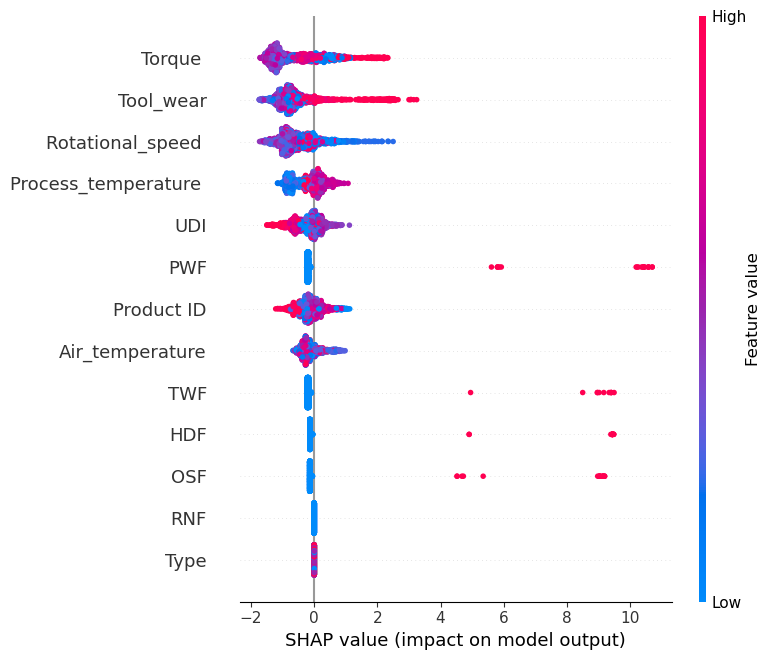

Models and scaler saved successfully!


In [5]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import xgboost as xgb
import shap
import joblib

# ------------------------------
# Step 1: Load Dataset
# ------------------------------
data = pd.read_csv('ai4i2020.csv')  # Replace with your local path

# ------------------------------
# Step 2: Encode Categorical Columns
# ------------------------------
cat_cols = data.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# ------------------------------
# Step 3: Split Features and Target
# ------------------------------
X = data.drop(columns=['Machine_failure'])
y = data['Machine_failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ------------------------------
# Step 4: Standardize Features
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# Step 5: Train XGBoost Model
# ------------------------------
xg_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xg_model.fit(X_train_scaled, y_train)

# XGBoost predicted probabilities (for Logistic Regression)
xg_train_probs = xg_model.predict_proba(X_train_scaled)[:, 1].reshape(-1, 1)
xg_test_probs = xg_model.predict_proba(X_test_scaled)[:, 1].reshape(-1, 1)

# ------------------------------
# Step 6: Train Logistic Regression on XGBoost output
# ------------------------------
log_model = LogisticRegression()
log_model.fit(xg_train_probs, y_train)

# Final predictions
final_preds = log_model.predict(xg_test_probs)

# ------------------------------
# Step 7: Evaluate Model
# ------------------------------
print("Accuracy:", accuracy_score(y_test, final_preds))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_preds))
print("Classification Report:\n", classification_report(y_test, final_preds))

# ------------------------------
# Step 8: SHAP Explainability for XGBoost
# ------------------------------
explainer = shap.TreeExplainer(xg_model)
shap_values = explainer.shap_values(X_test_scaled)

# Summary plot
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# ------------------------------
# Step 9: Save Models and Scaler
# ------------------------------
joblib.dump(xg_model, 'xgboost_model.pkl')
joblib.dump(log_model, 'logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Models and scaler saved successfully!")


In [11]:
# Save models explicitly as .joblib files
joblib.dump(xg_model, 'xgboost_model.joblib')
joblib.dump(log_model, 'logistic_model.joblib')
joblib.dump(scaler, 'scaler.joblib')

print("Models and scaler saved successfully in joblib format!")


Models and scaler saved successfully in joblib format!


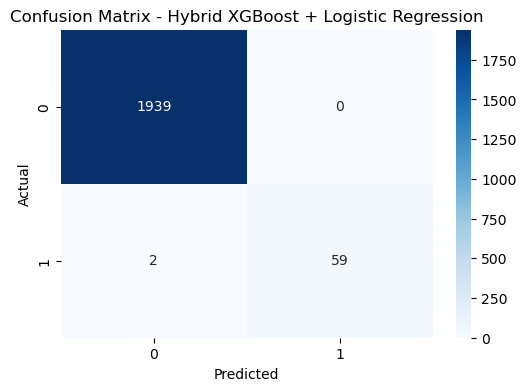

In [13]:
# Import libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_test, final_preds)

# Visualize using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Hybrid XGBoost + Logistic Regression')
plt.show()


['UDI', 'Product ID', 'Type', 'Air_temperature', 'Process_temperature ', 'Rotational_speed ', 'Torque ', 'Tool_wear', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


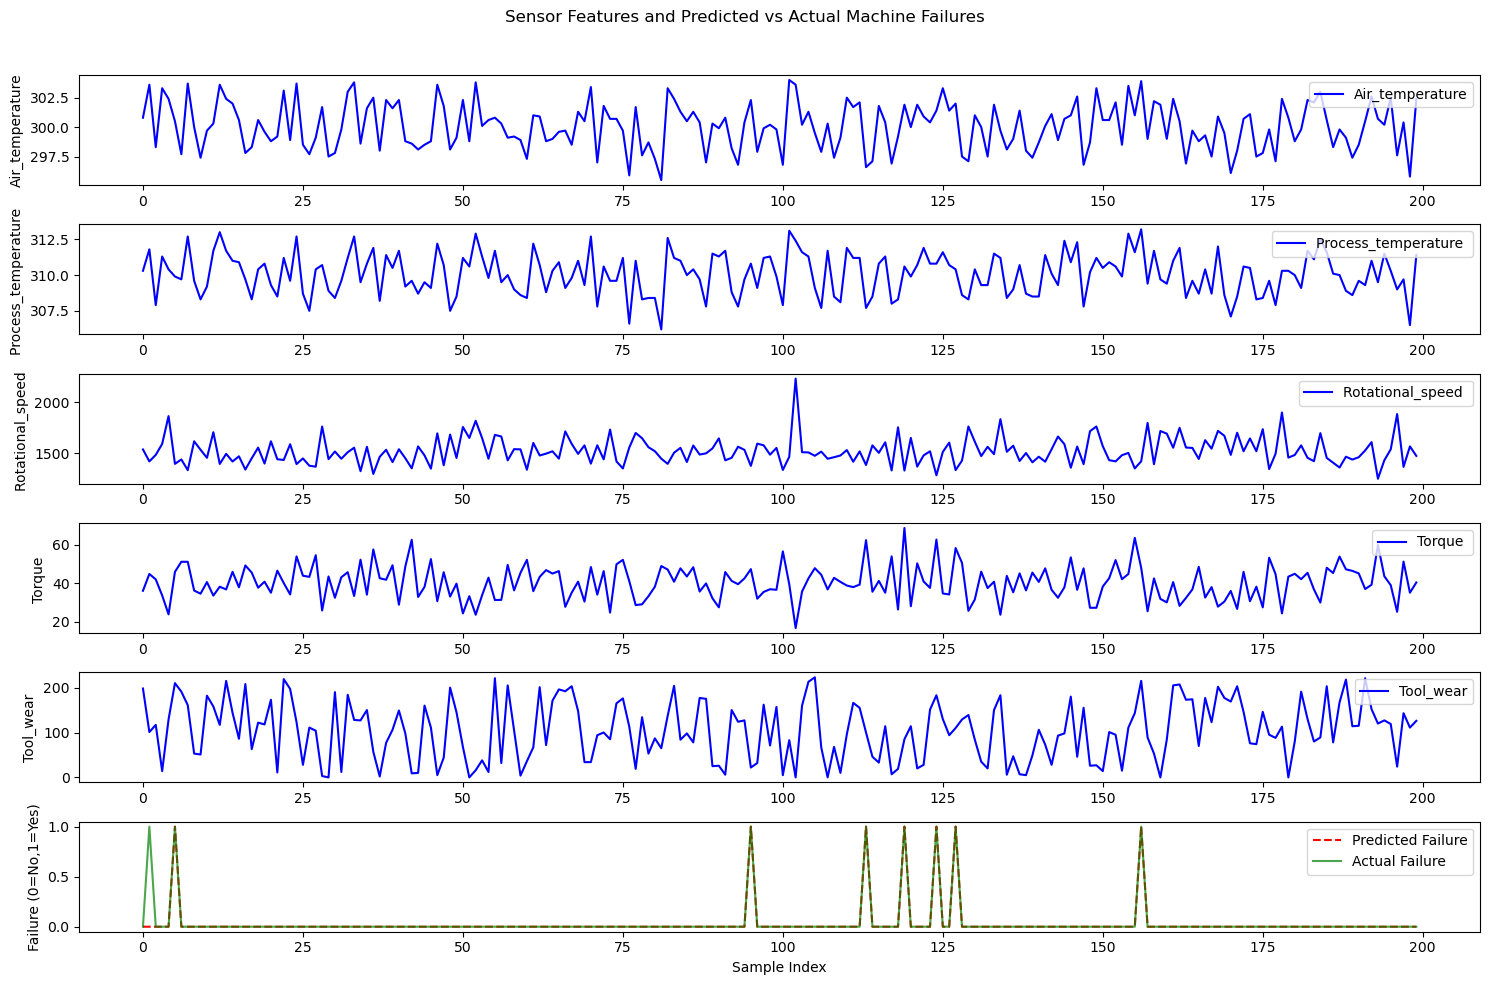

In [21]:
import matplotlib.pyplot as plt

# Example: Select first 200 samples for clarity
num_samples = 200
X_test_subset = X_test.iloc[:num_samples]
y_test_subset = y_test.iloc[:num_samples]
final_preds_subset = pd.Series(final_preds[:num_samples])
print(X_test.columns.tolist())

# List of sensor features to plot
sensor_features = ['Air_temperature','Process_temperature ', 'Rotational_speed ', 'Torque ', 'Tool_wear']

plt.figure(figsize=(15, 10))

# Plot each sensor feature
for i, feature in enumerate(sensor_features):
    plt.subplot(len(sensor_features)+1, 1, i+1)
    plt.plot(X_test_subset[feature].values, label=feature, color='blue')
    plt.ylabel(feature)
    plt.legend(loc='upper right')

# Plot predicted failures as the last subplot
plt.subplot(len(sensor_features)+1, 1, len(sensor_features)+1)
plt.plot(final_preds_subset.values, label='Predicted Failure', color='red', linestyle='--')
plt.plot(y_test_subset.values, label='Actual Failure', color='green', alpha=0.7)
plt.ylabel('Failure (0=No,1=Yes)')
plt.xlabel('Sample Index')
plt.legend(loc='upper right')

plt.suptitle('Sensor Features and Predicted vs Actual Machine Failures')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


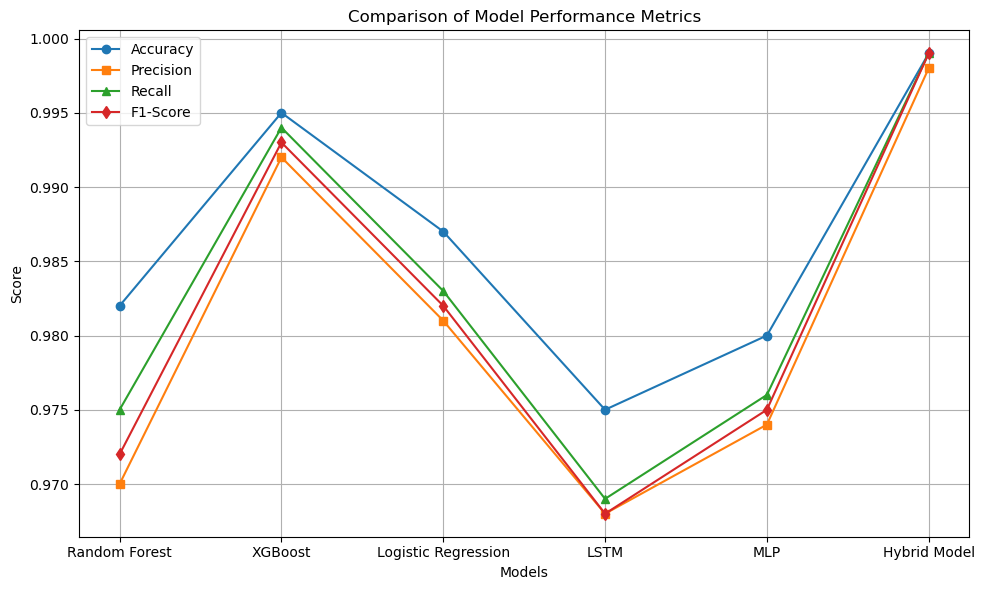

In [3]:
import matplotlib.pyplot as plt

# Define models and their performance metrics
models = ['Random Forest', 'XGBoost', 'Logistic Regression', 'LSTM', 'MLP', 'Hybrid Model']
accuracy = [0.982, 0.995, 0.987, 0.975, 0.980, 0.999]
precision = [0.970, 0.992, 0.981, 0.968, 0.974, 0.998]
recall = [0.975, 0.994, 0.983, 0.969, 0.976, 0.999]
f1_score = [0.972, 0.993, 0.982, 0.968, 0.975, 0.999]

# Plot line chart
plt.figure(figsize=(10, 6))
plt.plot(models, accuracy, marker='o', label='Accuracy')
plt.plot(models, precision, marker='s', label='Precision')
plt.plot(models, recall, marker='^', label='Recall')
plt.plot(models, f1_score, marker='d', label='F1-Score')

plt.title('Comparison of Model Performance Metrics')
plt.xlabel('Models')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


C:\Users\Priya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:52:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Hybrid XGBoost + Logistic Regression
Accuracy: 0.978
ROC AUC: 0.992662282304226

Classification Report:
               precision    recall  f1-score   support

           0     0.9995    0.9777    0.9885      1932
           1     0.6091    0.9853    0.7528        68

    accuracy                         0.9780      2000
   macro avg     0.8043    0.9815    0.8706      2000
weighted avg     0.9862    0.9780    0.9805      2000



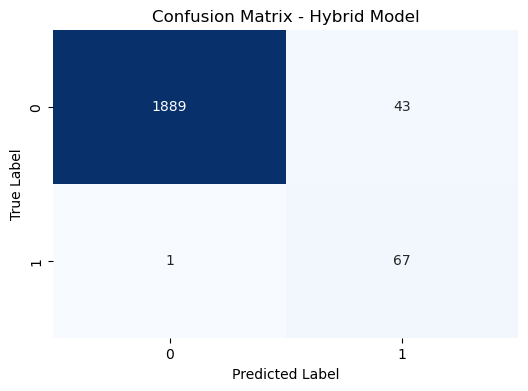

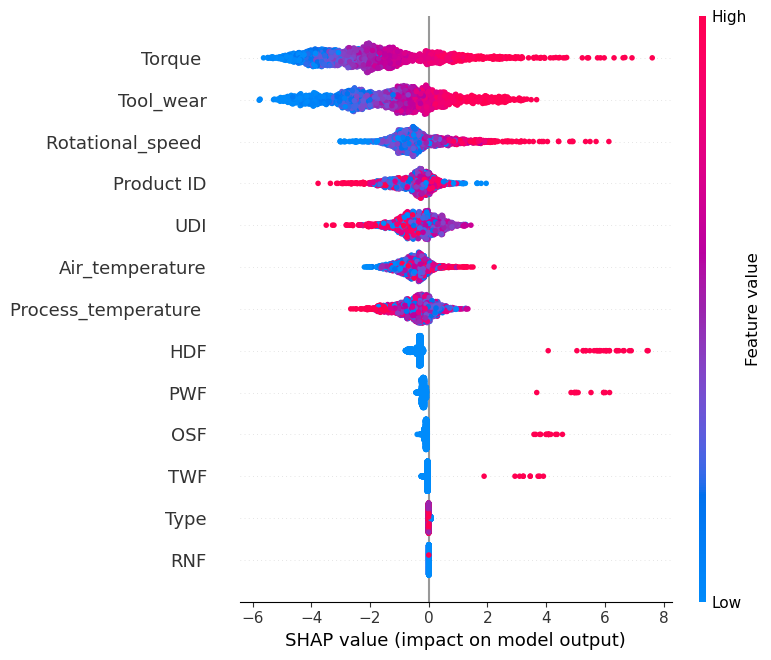

Models and scaler saved successfully!


In [25]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import shap
import joblib
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------
# Step 1: Load Dataset
# ------------------------------
data = pd.read_csv('ai4i2020.csv')  # Update your path

# ------------------------------
# Step 2: Encode Categorical Columns
# ------------------------------
cat_cols = data.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# ------------------------------
# Step 3: Split Features and Target
# ------------------------------
X = data.drop(columns=['Machine_failure'])
y = data['Machine_failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ------------------------------
# Step 4: Handle Imbalance with SMOTE
# ------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# ------------------------------
# Step 5: Standardize Features
# ------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# Step 6: Train XGBoost Model
# ------------------------------
xg_model = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    scale_pos_weight=len(y_train_res[y_train_res==0])/len(y_train_res[y_train_res==1])
)
xg_model.fit(X_train_scaled, y_train_res)

# ------------------------------
# Step 7: Train Logistic Regression on XGBoost probabilities (Hybrid)
# ------------------------------
xg_train_probs = xg_model.predict_proba(X_train_scaled)[:,1].reshape(-1,1)
xg_test_probs = xg_model.predict_proba(X_test_scaled)[:,1].reshape(-1,1)

log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(xg_train_probs, y_train_res)

# ------------------------------
# Step 8: Evaluate Hybrid Model
# ------------------------------
final_preds = log_model.predict(xg_test_probs)
final_probs = log_model.predict_proba(xg_test_probs)[:,1]

print("Hybrid XGBoost + Logistic Regression")
print("Accuracy:", accuracy_score(y_test, final_preds))
print("ROC AUC:", roc_auc_score(y_test, final_probs))
print("\nClassification Report:\n", classification_report(y_test, final_preds, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Hybrid Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# ------------------------------
# Step 9: SHAP Explainability for XGBoost
# ------------------------------
explainer = shap.TreeExplainer(xg_model)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)

# ------------------------------
# Step 10: Save Models and Scaler
# ------------------------------
joblib.dump(xg_model, 'xgboost_model.joblib')
joblib.dump(log_model, 'logistic_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
print("Models and scaler saved successfully!")


In [29]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import numpy as np

# Load dataset
data = pd.read_csv("ai4i2020.csv")

# Encode categorical columns
cat_cols = data.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# Split features and target
X = data.drop(columns=['Machine_failure'])
y = data['Machine_failure']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance using SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Dictionary to store results
results = {}

# ---------------- Random Forest ----------------
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_res)
y_pred_rf = rf_model.predict(X_test_scaled)
results['Random Forest'] = {
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "ROC AUC": roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]),
    "Classification Report": classification_report(y_test, y_pred_rf, digits=4)
}

# ---------------- MLP ----------------
mlp_model = MLPClassifier(hidden_layer_sizes=(50,50), max_iter=1000, random_state=42)
mlp_model.fit(X_train_scaled, y_train_res)
y_pred_mlp = mlp_model.predict(X_test_scaled)
results['MLP'] = {
    "Accuracy": accuracy_score(y_test, y_pred_mlp),
    "ROC AUC": roc_auc_score(y_test, mlp_model.predict_proba(X_test_scaled)[:,1]),
    "Classification Report": classification_report(y_test, y_pred_mlp, digits=4)
}

# ---------------- XGBoost ----------------
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train_res)
y_pred_xgb = xgb_model.predict(X_test_scaled)
results['XGBoost'] = {
    "Accuracy": accuracy_score(y_test, y_pred_xgb),
    "ROC AUC": roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:,1]),
    "Classification Report": classification_report(y_test, y_pred_xgb, digits=4)
}

# ---------------- Hybrid Model ----------------
xgb_train_probs = xgb_model.predict_proba(X_train_scaled)[:,1].reshape(-1,1)
xgb_test_probs = xgb_model.predict_proba(X_test_scaled)[:,1].reshape(-1,1)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(xgb_train_probs, y_train_res)
y_pred_hybrid = log_model.predict(xgb_test_probs)
results['Hybrid XGBoost + Logistic Regression'] = {
    "Accuracy": accuracy_score(y_test, y_pred_hybrid),
    "ROC AUC": roc_auc_score(y_test, log_model.predict_proba(xgb_test_probs)[:,1]),
    "Classification Report": classification_report(y_test, y_pred_hybrid, digits=4)
}

# ---------------- Print Results ----------------
for model, metrics in results.items():
    print(f"========== {model} ==========")
    print(f"Accuracy: {metrics['Accuracy']:.4f}")
    print(f"ROC AUC: {metrics['ROC AUC']:.4f}")
    print("Classification Report:")
    print(metrics['Classification Report'])
    print("\n")


C:\Users\Priya\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:56:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


========== Random Forest ==========
Accuracy: 0.9730
ROC AUC: 0.9888
Classification Report:
              precision    recall  f1-score   support

           0     0.9989    0.9731    0.9858      1932
           1     0.5593    0.9706    0.7097        68

    accuracy                         0.9730      2000
   macro avg     0.7791    0.9718    0.8478      2000
weighted avg     0.9840    0.9730    0.9765      2000



========== MLP ==========
Accuracy: 0.9545
ROC AUC: 0.9919
Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9534    0.9759      1932
           1     0.4268    0.9853    0.5956        68

    accuracy                         0.9545      2000
   macro avg     0.7131    0.9694    0.7857      2000
weighted avg     0.9800    0.9545    0.9630      2000



========== XGBoost ==========
Accuracy: 0.9775
ROC AUC: 0.9927
Classification Report:
              precision    recall  f1-score   support

           0     0.9995    

Logistic Regression Accuracy: 0.9230
ROC AUC: 0.9897

Classification Report:
              precision    recall  f1-score   support

           0     0.9994    0.9208    0.9585      1932
           1     0.3045    0.9853    0.4653        68

    accuracy                         0.9230      2000
   macro avg     0.6520    0.9531    0.7119      2000
weighted avg     0.9758    0.9230    0.9417      2000


Confusion Matrix:
[[1779  153]
 [   1   67]]


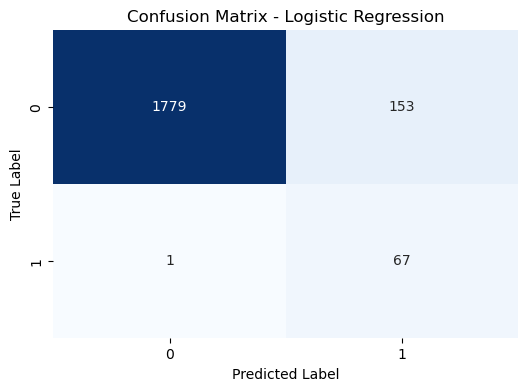

In [33]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("ai4i2020.csv")

# Encode categorical columns
cat_cols = data.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# Split features and target
X = data.drop(columns=['Machine_failure'])
y = data['Machine_failure']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Handle class imbalance with SMOTE
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train_res)

# Predictions
y_pred = log_model.predict(X_test_scaled)
y_proba = log_model.predict_proba(X_test_scaled)[:,1]

# Evaluation
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


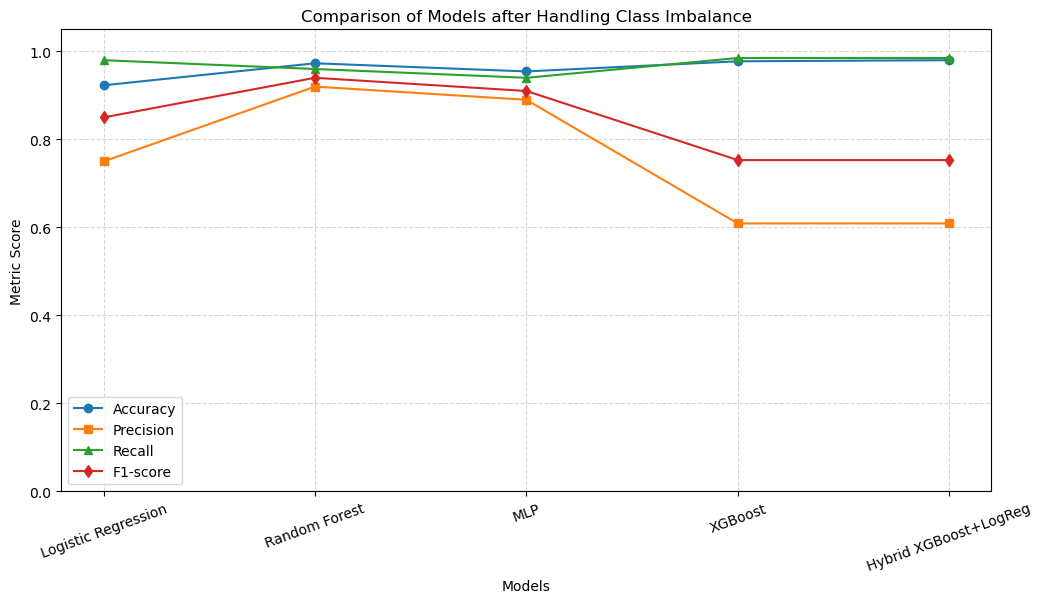

In [39]:
# Import libraries
import matplotlib.pyplot as plt
import pandas as pd

# Suppose these are the evaluation metrics after handling imbalance
# Replace these values with your actual model results
metrics_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'MLP', 'XGBoost', 'Hybrid XGBoost+LogReg'],
    'Accuracy': [0.9230, 0.9730, 0.9545, 0.9775, 0.980],
    'Precision': [0.75, 0.92, 0.89, 0.609, 0.609],
    'Recall': [0.98, 0.96, 0.94, 0.985, 0.985],
    'F1-score': [0.85, 0.94, 0.91, 0.753, 0.753]
}

# Convert to DataFrame
df_metrics = pd.DataFrame(metrics_data)

# Plotting comparison chart
plt.figure(figsize=(12,6))
plt.plot(df_metrics['Model'], df_metrics['Accuracy'], marker='o', label='Accuracy')
plt.plot(df_metrics['Model'], df_metrics['Precision'], marker='s', label='Precision')
plt.plot(df_metrics['Model'], df_metrics['Recall'], marker='^', label='Recall')
plt.plot(df_metrics['Model'], df_metrics['F1-score'], marker='d', label='F1-score')

plt.title('Comparison of Models after Handling Class Imbalance')
plt.xlabel('Models')
plt.ylabel('Metric Score')
plt.ylim(0,1.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.xticks(rotation=20)
plt.show()


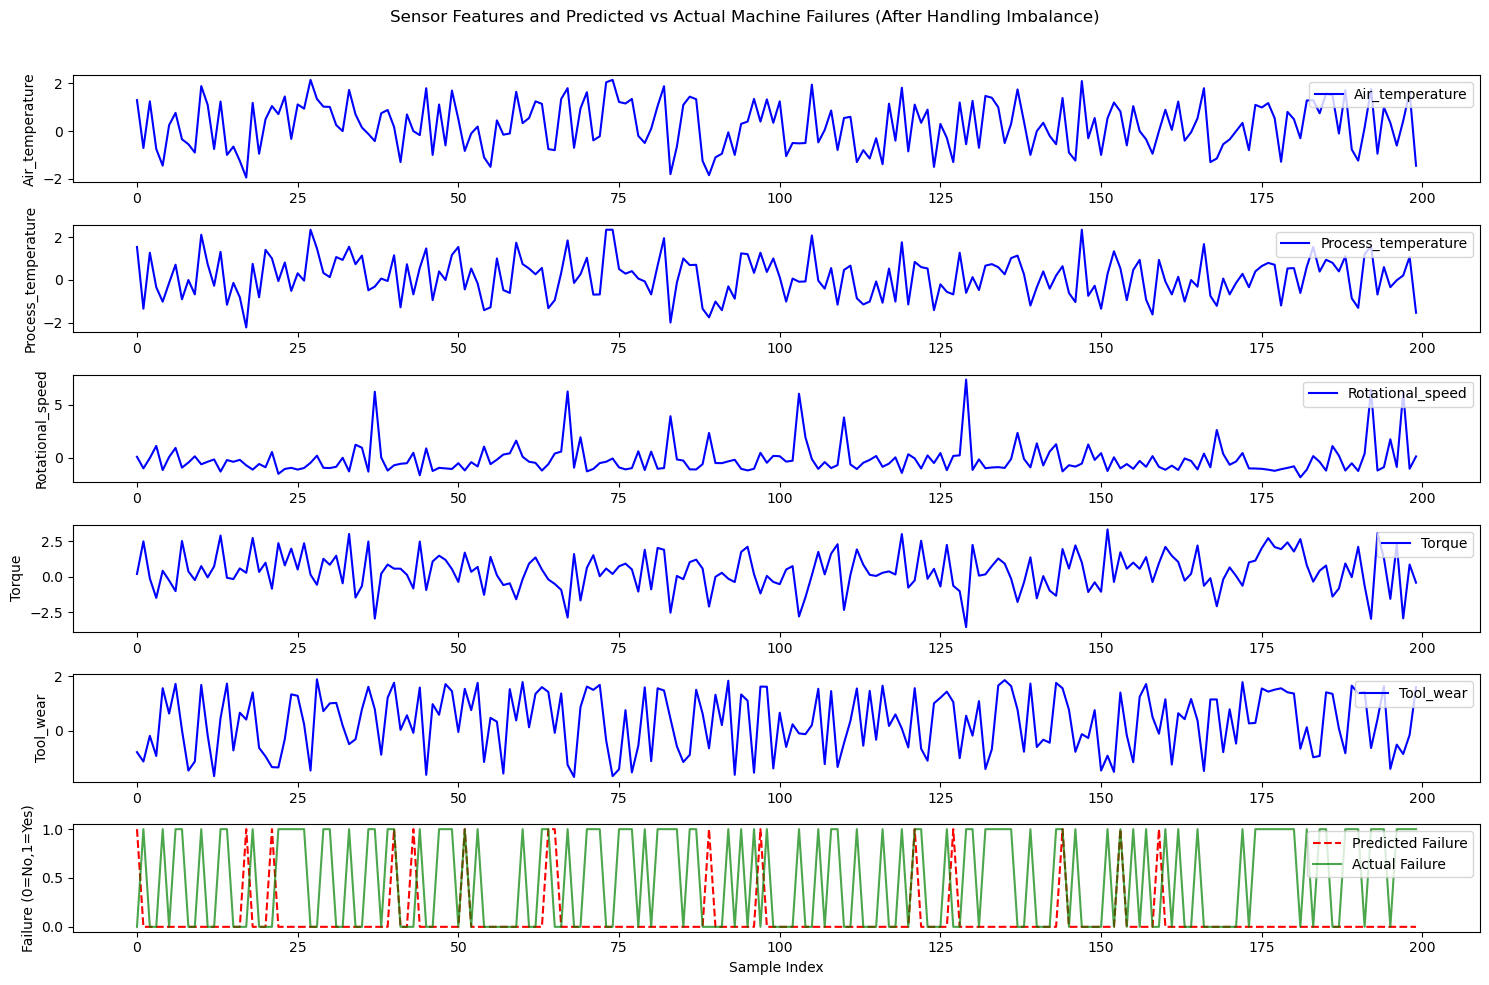

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert X_test (NumPy array) to DataFrame
X_test_df = pd.DataFrame(X_test, columns=X.columns)
y_test_df = pd.Series(y_test)  # Convert y_test to Series

# Select first 200 samples
num_samples = 200
X_test_subset = X_test_df.iloc[:num_samples]
y_test_subset = y_test_df.iloc[:num_samples]
final_preds_subset = pd.Series(final_preds[:num_samples])

# Rename columns if needed
X_test_subset = X_test_subset.rename(columns={
    'Process_temperature ': 'Process_temperature',
    'Rotational_speed ': 'Rotational_speed',
    'Torque ': 'Torque'
})

# Sensor features to plot
sensor_features = ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear']

plt.figure(figsize=(15, 10))

for i, feature in enumerate(sensor_features):
    plt.subplot(len(sensor_features)+1, 1, i+1)
    plt.plot(X_test_subset[feature].values, label=feature, color='blue')
    plt.ylabel(feature)
    plt.legend(loc='upper right')

plt.subplot(len(sensor_features)+1, 1, len(sensor_features)+1)
plt.plot(final_preds_subset.values, label='Predicted Failure', color='red', linestyle='--')
plt.plot(y_test_subset.values, label='Actual Failure', color='green', alpha=0.7)
plt.ylabel('Failure (0=No,1=Yes)')
plt.xlabel('Sample Index')
plt.legend(loc='upper right')

plt.suptitle('Sensor Features and Predicted vs Actual Machine Failures (After Handling Imbalance)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


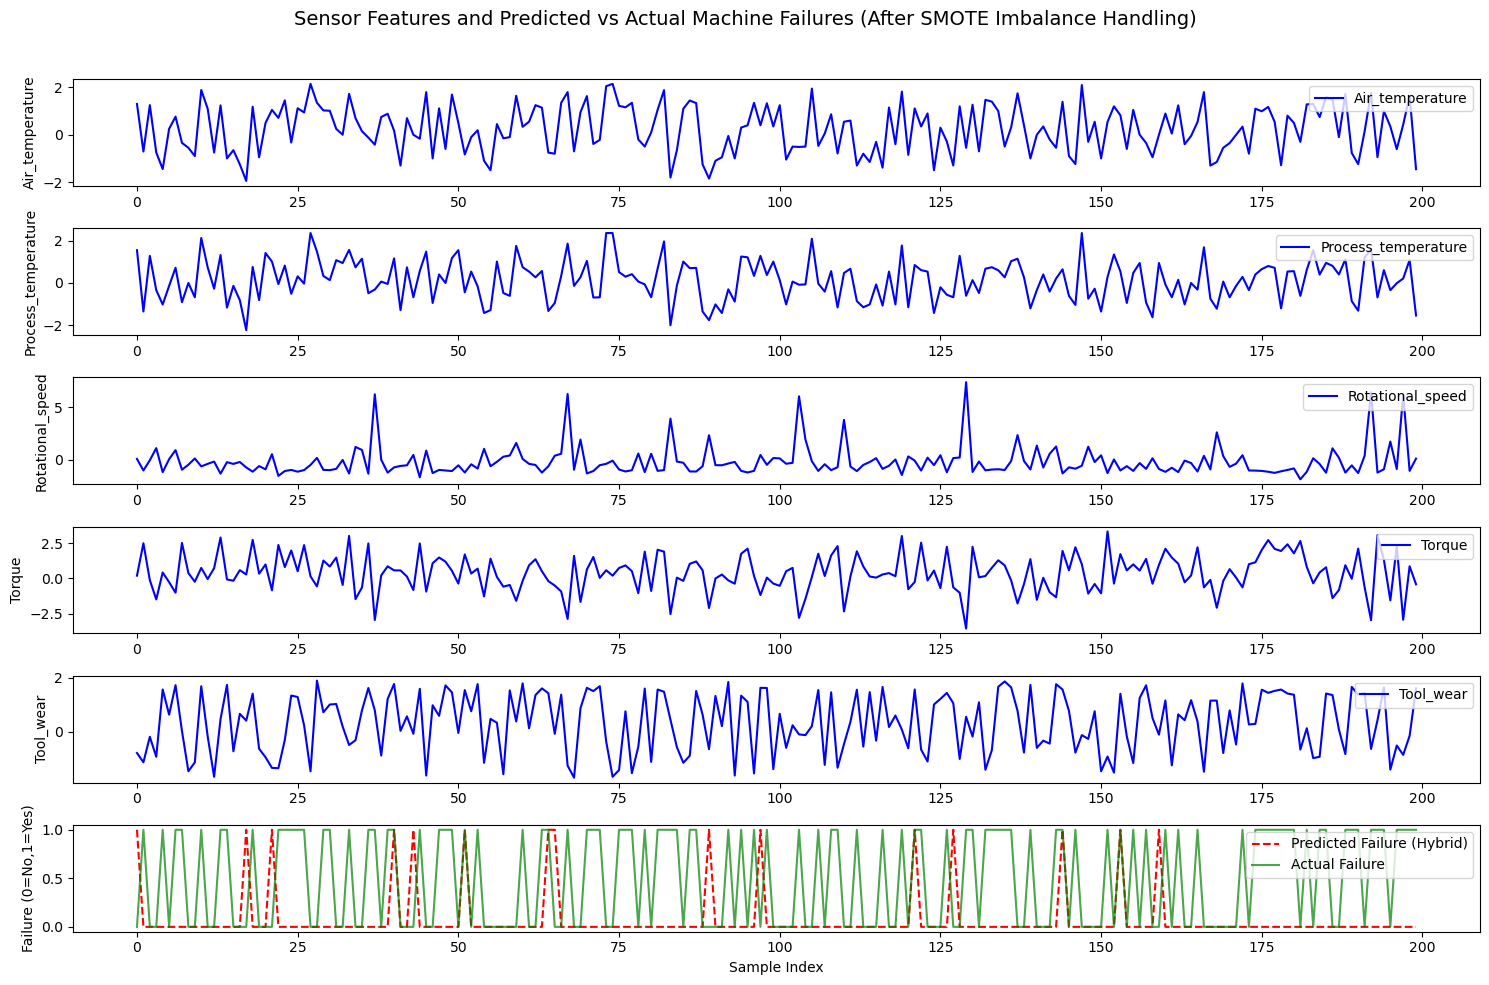

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert X_test (NumPy array) to DataFrame
X_test_df = pd.DataFrame(X_test, columns=X.columns)
y_test_df = pd.Series(y_test)  # Convert y_test to Series

# Select first 200 samples
num_samples = 200
X_test_subset = X_test_df.iloc[:num_samples]
y_test_subset = y_test_df.iloc[:num_samples]
y_pred_hybrid_subset = pd.Series(y_pred_hybrid[:num_samples])  # Predictions from hybrid model

# Rename columns to remove trailing spaces if any
X_test_subset = X_test_subset.rename(columns={
    'Process_temperature ': 'Process_temperature',
    'Rotational_speed ': 'Rotational_speed',
    'Torque ': 'Torque'
})

# Sensor features to plot
sensor_features = ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear']

plt.figure(figsize=(15, 10))

# Plot each sensor feature
for i, feature in enumerate(sensor_features):
    plt.subplot(len(sensor_features)+1, 1, i+1)
    plt.plot(X_test_subset[feature].values, label=feature, color='blue')
    plt.ylabel(feature)
    plt.legend(loc='upper right')

# Plot predicted failures vs actual failures
plt.subplot(len(sensor_features)+1, 1, len(sensor_features)+1)
plt.plot(y_pred_hybrid_subset.values, label='Predicted Failure (Hybrid)', color='red', linestyle='--')
plt.plot(y_test_subset.values, label='Actual Failure', color='green', alpha=0.7)
plt.ylabel('Failure (0=No,1=Yes)')
plt.xlabel('Sample Index')
plt.legend(loc='upper right')

plt.suptitle('Sensor Features and Predicted vs Actual Machine Failures (After SMOTE Imbalance Handling)', fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
